# Why can't reward regressors be predicted from neural activity?

`RRRToExternalLatentsConfig` finds that RRR latents predict the **position** basis functions well but the
**reward** basis functions essentially not at all. That is odd — CA1 should encode reward somewhat, and even pure
collinearity with position would make reward columns predictable.

Hypotheses:

1. **Nuisance hyperparameters** — reward adds little beyond position+speed, so the optimizer lands on an
   arbitrary reward basis shape that is hard to predict.
2. **Bad encoding** — the regressors fail to capture reward structure even though neurons encode it.
3. **Speed filter** — `PopulationRegistry` keeps only frames with `speed >= 1 cm/s`. Mice slow down to lick, so
   the post-reward frames where a response would live may be deleted before the model ever sees them.

**Model choice.** This notebook uses `EXTERNAL_MODEL_NAME = "fullregressor_decoder_only_1dspeed"`, whose decoder
is fed the true behavior-derived basis. It deliberately does *not* use a `_leak` model. A leak model trains its
encoder and decoder on the same split, which lets the basis act as a generic rank/capacity channel between source
and target activity — extra basis columns then improve validation for reasons unrelated to what the regressors
represent. With a decoder-only model there is no such channel, so §8's ablation is a faithful test of the model's
own objective, and §5 fits its own activity-to-basis map rather than inheriting a contaminated one.

Single example session throughout; every entry point takes `session` so this lifts into a cohort sweep later.

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from dataclasses import replace

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import kurtosis
from rastermap import Rastermap

from dimilibi import RidgeRegression
from dimilibi.metrics import measure_r2
from vrAnalysis.database import get_database
from vrAnalysis.sessions import B2Session
from vrAnalysis.helpers.plotting import beeswarm
from vrAnalysis.processors.support import median_zscore
from vrAnalysis.processors.placefields import get_frame_behavior, get_placefield, get_placefield_prediction

from dimensionality_manuscript.registry import PopulationRegistry, get_model
from dimensionality_manuscript.configs import get_data_config
from dimensionality_manuscript.configs.rrr_to_external_latents import DEFAULT_MODEL_EXT_INT_PAIR, _pos_speed_reward_dims

# The (external, internal) model pair is a config parameter now; this notebook only interrogates
# the external (decoder-only) member of the default pair.
EXTERNAL_MODEL_NAME = DEFAULT_MODEL_EXT_INT_PAIR[0]

plt.rcParams["font.size"] = 12

# Example session -- same one used in figure_scripts/figure1.py so panels are comparable.
EXAMPLE_MOUSE_NAME = "ATL027"
EXAMPLE_DATE = "2023-07-27"
EXAMPLE_SESSION_ID = "701"
EXAMPLE_SPKS_TYPE = "sigrebase"
ACTIVITY_PARAMETERS_NAME = "default"
HYPERPARAMETER_METHOD = "preferred"

session = B2Session.create(EXAMPLE_MOUSE_NAME, EXAMPLE_DATE, EXAMPLE_SESSION_ID)
registry = PopulationRegistry(registry_params=get_data_config("default").to_registry_params())

print(session.session_print(), "|", EXTERNAL_MODEL_NAME)

ATL027/2023-07-27/701 | fullregressor_decoder_only_1dspeed


## 1. Entry points

Pure `session -> dict` functions with no plotting, so they can be dropped into an `AnalysisConfigBase.process`
for a cohort sweep. Block widths come from `build_regressors(as_list=True)` shapes rather than the
`4 * lags + 3` formula, because `make_temporal_basis(remove_empty=True)` can drop empty columns.

In [2]:
BLOCK_NAMES = ("position", "speed", "reward_expectation", "reward_delivery", "reward_omission")
REWARD_BLOCKS = ("reward_expectation", "reward_delivery", "reward_omission")
NONREWARD_BLOCKS = ("position", "speed")


def _tt(x: np.ndarray) -> torch.Tensor:
    """Coerce to a float32 torch tensor (what dimilibi's RidgeRegression expects)."""
    return torch.as_tensor(np.asarray(x), dtype=torch.float32)


def _block_slices(blocks: list[np.ndarray]) -> dict[str, slice]:
    """Map block name -> column slice, using the true widths of the built regressor blocks."""
    slices, start = {}, 0
    for name, block in zip(BLOCK_NAMES, blocks):
        slices[name] = slice(start, start + block.shape[1])
        start += block.shape[1]
    return slices


def _block_labels(block_slices: dict[str, slice], num_columns: int) -> np.ndarray:
    labels = np.empty(num_columns, dtype=object)
    for name, sl in block_slices.items():
        labels[sl] = name
    return labels


def _columns_of(block_slices: dict[str, slice], names) -> np.ndarray:
    """Concatenated column indices for a set of block names."""
    num_columns = max(sl.stop for sl in block_slices.values())
    all_columns = np.arange(num_columns)
    return np.concatenate([all_columns[block_slices[name]] for name in names])


def build_reward_bundle(
    session,
    registry,
    spks_type: str = EXAMPLE_SPKS_TYPE,
    activity_parameters_name: str = ACTIVITY_PARAMETERS_NAME,
    method: str = HYPERPARAMETER_METHOD,
) -> dict:
    """Fit the external leak model and package everything the reward analyses need.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    registry : PopulationRegistry
        Registry defining the time/cell splits and the speed filter.
    spks_type : str
        Spike type for the population.
    activity_parameters_name : str
        Activity scaling preset name.
    method : str
        Hyperparameter optimization method passed to ``get_best_hyperparameters``.

    Returns
    -------
    dict
        Keys ``model``, ``hyperparameters``, ``decoder``, ``block_slices``, ``basis_true``
        (test-split regressors), ``report``, ``frame_behavior_full``, and per-split dicts under
        ``"train"``/``"test"`` holding ``source``, ``target``, ``frame_behavior``, ``blocks``
        and concatenated ``regressors``.

        ``EXTERNAL_MODEL_NAME`` is a decoder-only model (``predict_latents=False``), so
        ``train`` returns a single decoder and there is no encoder and no predicted basis.
        Sections that need an activity-to-basis map fit their own — see
        :func:`fit_basis_encoder`.
    """
    model = get_model(EXTERNAL_MODEL_NAME, registry, activity_parameters=activity_parameters_name)
    if model.predict_latents:
        raise ValueError(f"{EXTERNAL_MODEL_NAME!r} is expected to be decoder-only (predict_latents=False).")
    hyperparameters = model.get_best_hyperparameters(session, spks_type=spks_type, method=method)[0]
    report = model.process(session, spks_type=spks_type, hyperparameters=hyperparameters)
    decoder = report.trained_model

    # predict() drops NaN samples from the test split; the encoder's basis arrays are already
    # filtered, so the recomputed test regressors must be filtered the same way to stay aligned.
    idx_valid_test = report.extras["idx_valid_predictions"] if report.extras.get("predictions_were_filtered", False) else None

    def _split(split, idx_valid=None):
        source, target, frame_behavior = model.get_session_data(session, spks_type, split)
        blocks = [np.asarray(b) for b in model.build_regressors(session, frame_behavior, hyperparameters, as_list=True)]
        if idx_valid is not None:
            blocks = [b[idx_valid] for b in blocks]
            frame_behavior = frame_behavior.filter(idx_valid)
            source, target = source[:, idx_valid], target[:, idx_valid]
        return dict(
            source=source,
            target=target,
            frame_behavior=frame_behavior,
            blocks=blocks,
            regressors=np.concatenate(blocks, axis=1),
        )

    bundle = dict(
        session=session,
        registry=registry,
        model=model,
        spks_type=spks_type,
        hyperparameters=hyperparameters,
        decoder=decoder,
        report=report,
        basis_true=np.asarray(report.extras["basis_functions"]),
        frame_behavior_full=get_frame_behavior(session, clear_one_cache=False),
        train=_split("train"),
        test=_split("test", idx_valid_test),
    )
    bundle["block_slices"] = _block_slices(bundle["train"]["blocks"])
    bundle["block_labels"] = _block_labels(bundle["block_slices"], bundle["basis_true"].shape[1])
    return bundle


def reward_frame_retention(session, registry, max_lag: int = 30) -> dict:
    """Fraction of frames at each lag from a reward event that survive the registry's speed filter.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    registry : PopulationRegistry
        Supplies ``speed_threshold``.
    max_lag : int
        Half-width, in imaging frames, of the lag window around each reward event.

    Returns
    -------
    dict
        ``lags``, per-event-type retention curves, event counts, and the session-wide retention rate.
    """
    frame_behavior = get_frame_behavior(session, clear_one_cache=False)
    fast = frame_behavior.speed >= registry.registry_params.speed_threshold
    kept = frame_behavior.valid_frames() & fast
    num_frames = len(kept)
    lags = np.arange(-max_lag, max_lag + 1)

    out = {"lags": lags, "overall_retention": float(kept.mean())}
    for name, mask in (("delivery", frame_behavior.reward_delivery), ("omission", frame_behavior.reward_omitted)):
        events = np.where(mask)[0]
        retention = np.full(len(lags), np.nan)
        for i, lag in enumerate(lags):
            idx = events + lag
            idx = idx[(idx >= 0) & (idx < num_frames)]
            if len(idx):
                retention[i] = kept[idx].mean()
        out[name] = retention
        out[f"n_{name}"] = int(len(events))
    return out


def regressor_collinearity(bundle: dict, alpha: float = 1.0) -> pd.DataFrame:
    """Cross-validated R^2 of predicting every regressor column from the position+speed columns.

    Fit on the train split, scored on the test split, so a high value genuinely means the column is
    redundant with position/speed rather than merely in their span.

    Parameters
    ----------
    bundle : dict
        Output of :func:`build_reward_bundle`.
    alpha : float
        Ridge penalty.

    Returns
    -------
    pandas.DataFrame
        Columns ``column``, ``block``, ``r2_from_pos_speed``.
    """
    block_slices = bundle["block_slices"]
    idx_nonreward = _columns_of(block_slices, NONREWARD_BLOCKS)
    Xtrain = _tt(bundle["train"]["regressors"][:, idx_nonreward])
    Xtest = _tt(bundle["test"]["regressors"][:, idx_nonreward])
    Ytrain = _tt(bundle["train"]["regressors"])
    Ytest = _tt(bundle["test"]["regressors"])

    fit = RidgeRegression(alpha=alpha, fit_intercept=True).fit(Xtrain, Ytrain)
    r2 = fit.score(Xtest, Ytest, dim=0, reduce="none").numpy()
    return pd.DataFrame(
        {
            "column": np.arange(len(r2)),
            "block": bundle["block_labels"],
            "r2_from_pos_speed": r2,
        }
    )


def regressor_stats(bundle: dict, split: str = "train") -> pd.DataFrame:
    """Per-column scale and sparsity of the regressors.

    Parameters
    ----------
    bundle : dict
        Output of :func:`build_reward_bundle`.
    split : str
        Which split's regressors to describe.

    Returns
    -------
    pandas.DataFrame
        Columns ``column``, ``block``, ``std``, ``fraction_nonzero``, ``kurtosis``.
    """
    X = bundle[split]["regressors"]
    return pd.DataFrame(
        {
            "column": np.arange(X.shape[1]),
            "block": bundle["block_labels"],
            "std": X.std(axis=0),
            "fraction_nonzero": (np.abs(X) > 1e-12).mean(axis=0),
            "kurtosis": kurtosis(X, axis=0),
        }
    )


ENCODER_ALPHAS = (1.0, 10.0, 100.0, 1e3, 1e4, 1e5)


def encoder_data(session, model, hyperparameters, spks_type: str) -> dict:
    """Source activity and regressor targets for train / validation / test.

    Shared by :func:`fit_basis_encoder` and :func:`reward_basis_sweep`.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    model : FullRegressorModel
        Supplies the split data and the regressor construction.
    hyperparameters : FullRegressorHyperparameters
        Determines the regressor shapes.
    spks_type : str
        Spike type.

    Returns
    -------
    dict
        Split name -> dict with ``X`` (frames, neurons), ``blocks``, ``Y`` (concatenated
        regressors as a tensor) and ``frame_behavior``.
    """
    out = {}
    for split in ("train", "validation", "test"):
        source, _, frame_behavior = model.get_session_data(session, spks_type, split)
        blocks = [np.asarray(b) for b in model.build_regressors(session, frame_behavior, hyperparameters, as_list=True)]
        out[split] = dict(
            X=source.T.contiguous(),
            blocks=blocks,
            Y=_tt(np.concatenate(blocks, axis=1)),
            frame_behavior=frame_behavior,
        )
    return out


def fit_basis_encoder(session, bundle: dict, hyperparameters=None, alphas=ENCODER_ALPHAS) -> pd.DataFrame:
    """Fit our own activity-to-basis encoder and score every basis column on test.

    ``EXTERNAL_MODEL_NAME`` is decoder-only, so it has no encoder to interrogate. This fits the
    equivalent map — source activity to the true (behavior-derived) basis — on the train split,
    picks one global ridge alpha on validation (as a single shared encoder would), and scores
    each column on test. The ReLU matches ``model.nonnegative``.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    bundle : dict
        Output of :func:`build_reward_bundle`.
    hyperparameters : FullRegressorHyperparameters or None
        Regressor shape. Defaults to the bundle's optimized hyperparameters.
    alphas : iterable of float
        Ridge penalties searched on validation.

    Returns
    -------
    pandas.DataFrame
        Columns ``column``, ``block``, ``r2_encoder``, plus the selected ``alpha``.
    """
    model = bundle["model"]
    hyperparameters = hyperparameters if hyperparameters is not None else bundle["hyperparameters"]
    data = encoder_data(session, model, hyperparameters, bundle["spks_type"])

    best_alpha, best_val = None, -np.inf
    for alpha in alphas:
        fit = RidgeRegression(alpha=alpha, fit_intercept=True).fit(data["train"]["X"], data["train"]["Y"])
        score = float(fit.score(data["validation"]["X"], data["validation"]["Y"], nonnegative=True, dim=None))
        if score > best_val:
            best_alpha, best_val = alpha, score

    fit = RidgeRegression(alpha=best_alpha, fit_intercept=True).fit(data["train"]["X"], data["train"]["Y"])
    r2 = fit.score(data["test"]["X"], data["test"]["Y"], nonnegative=True, dim=0, reduce="none").numpy()
    block_labels = _block_labels(_block_slices(data["train"]["blocks"]), len(r2))
    return pd.DataFrame({"column": np.arange(len(r2)), "block": block_labels, "r2_encoder": r2, "alpha": best_alpha})


def rta_activity(session, registry, spks_type: str = EXAMPLE_SPKS_TYPE) -> dict:
    """Activity in full-session frame coordinates, all frames and speed-filtered.

    Both arrays use the same ROI set so the two RTAs are directly comparable. The filtered array is
    NaN wherever the registry's speed/validity filter drops a frame, so ``np.nanmean`` over an event
    window naturally reports what the model can actually see.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    registry : PopulationRegistry
        Supplies the filtered frame set.
    spks_type : str
        Spike type.

    Returns
    -------
    dict
        ``all`` and ``filtered`` activity arrays (frames, rois), plus ``idx_kept`` and ``frame_behavior``.
    """
    session.params.spks_type = spks_type
    spks = median_zscore(session.spks[:, session.idx_rois], median_subtract=not session.zero_baseline_spks)
    _, frame_behavior = registry.get_population(session, spks_type)

    filtered = np.full_like(spks, np.nan)
    filtered[frame_behavior.idx] = spks[frame_behavior.idx]
    return dict(all=spks, filtered=filtered, idx_kept=frame_behavior.idx, frame_behavior=frame_behavior)


def placefield_residual(session, registry, spks_type: str = EXAMPLE_SPKS_TYPE, num_bins: int = 100, smooth_width: float = 5.0) -> np.ndarray:
    """Activity with its place-field prediction subtracted, in full-session frame coordinates.

    Frames outside the registry's filtered set are NaN (no place-field prediction exists for them).

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    registry : PopulationRegistry
        Supplies the filtered frame set used to estimate the place fields.
    spks_type : str
        Spike type.
    num_bins : int
        Number of spatial bins.
    smooth_width : float
        Gaussian smoothing width for the place-field maps, in spatial units.

    Returns
    -------
    numpy.ndarray
        Residual activity, shape (frames, rois).
    """
    session.params.spks_type = spks_type
    spks = median_zscore(session.spks[:, session.idx_rois], median_subtract=not session.zero_baseline_spks)
    _, frame_behavior = registry.get_population(session, spks_type)

    dist_edges = np.linspace(0, session.env_length[0], num_bins + 1)
    placefield = get_placefield(
        spks[frame_behavior.idx],
        frame_behavior,
        dist_edges,
        speed_threshold=None,  # registry already applied the speed filter
        average=True,
        smooth_width=smooth_width,
        zero_to_nan=True,
    )
    prediction = get_placefield_prediction(placefield, frame_behavior)[0]

    residual = np.full_like(spks, np.nan)
    residual[frame_behavior.idx] = spks[frame_behavior.idx] - prediction
    return residual


def reward_triggered_average(
    activity: np.ndarray,
    event_mask: np.ndarray,
    window: tuple[int, int] = (-15, 30),
    baseline_lags: int = 10,
    num_shuffles: int = 100,
    seed: int = 0,
) -> dict:
    """Reward-triggered average per neuron, with a circular-shift null.

    Events are circularly shifted (rather than the activity) to build the null, which is equivalent
    and much cheaper. NaN frames are ignored via ``nanmean``.

    Parameters
    ----------
    activity : numpy.ndarray
        Activity in full-session frame coordinates, shape (frames, rois). May contain NaN.
    event_mask : numpy.ndarray
        Boolean mask of event frames, shape (frames,).
    window : tuple of int
        Inclusive lag window in imaging frames, relative to the event.
    baseline_lags : int
        Number of leading lags averaged to define each neuron's pre-event baseline.
    num_shuffles : int
        Number of circular shifts used for the null distribution.
    seed : int
        RNG seed.

    Returns
    -------
    dict
        ``lags``, ``rta`` (lags, rois), ``modulation`` (peak deviation from baseline per roi),
        ``modulation_z`` (z-scored against the null), and ``num_events``.
    """
    num_frames = activity.shape[0]
    events = np.where(event_mask)[0]
    lags = np.arange(window[0], window[1] + 1)

    def _average(event_indices):
        idx = (event_indices[:, None] + lags[None, :]) % num_frames
        return np.nanmean(activity[idx], axis=0)  # (events, lags, rois) -> (lags, rois)

    def _peak(rta):
        baseline = np.nanmean(rta[:baseline_lags], axis=0, keepdims=True)
        return np.nanmax(np.abs(rta - baseline), axis=0)

    rta = _average(events)
    modulation = _peak(rta)

    rng = np.random.default_rng(seed)
    null = np.stack([_peak(_average((events + rng.integers(num_frames)) % num_frames)) for _ in range(num_shuffles)])
    null_mean, null_std = np.nanmean(null, axis=0), np.nanstd(null, axis=0)

    return dict(
        lags=lags,
        rta=rta,
        modulation=modulation,
        modulation_z=(modulation - null_mean) / np.where(null_std > 0, null_std, np.nan),
        num_events=int(len(events)),
    )


def block_contributions(bundle: dict, split: str = "test") -> dict:
    """Per-neuron amplitude of each regressor block's contribution to the decoder prediction.

    Raw coefficient norms are not comparable across blocks because the regressors differ in scale by
    orders of magnitude, so the headline measure is the temporal standard deviation of each block's
    partial prediction ``X_block @ beta_block``.

    Parameters
    ----------
    bundle : dict
        Output of :func:`build_reward_bundle`.
    split : str
        Split whose regressors are used to evaluate the partial predictions.

    Returns
    -------
    dict
        ``contribution_std`` and ``coefficient_norm``, each a block-name -> per-neuron array, plus
        the raw ``beta`` matrix (regressor rows first, intercept last).
    """
    beta = bundle["decoder"]._beta_ols.numpy()  # (num_regressors + 1, num_neurons); intercept is the last row
    X = bundle[split]["regressors"]
    block_slices = bundle["block_slices"]
    return dict(
        contribution_std={name: (X[:, sl] @ beta[sl]).std(axis=0) for name, sl in block_slices.items()},
        coefficient_norm={name: np.linalg.norm(beta[sl], axis=0) for name, sl in block_slices.items()},
        beta=beta,
    )


def reward_ablation(bundle: dict) -> dict:
    """Per-neuron test R^2 with and without the reward regressor blocks.

    Refits the decoder on the train split both ways using the model's own decoder alpha, so the delta
    isolates what reward adds beyond position and speed.

    Parameters
    ----------
    bundle : dict
        Output of :func:`build_reward_bundle`.

    Returns
    -------
    dict
        ``r2_full``, ``r2_ablated``, ``delta_r2``, each per target neuron.
    """
    alpha = bundle["hyperparameters"].alpha_decoder
    keep = _columns_of(bundle["block_slices"], NONREWARD_BLOCKS)

    Xtrain, Ytrain = bundle["train"]["regressors"], bundle["train"]["target"].numpy().T
    Xtest, Ytest = bundle["test"]["regressors"], bundle["test"]["target"].numpy().T

    full = RidgeRegression(alpha=alpha, fit_intercept=True).fit(_tt(Xtrain), _tt(Ytrain))
    ablated = RidgeRegression(alpha=alpha, fit_intercept=True).fit(_tt(Xtrain[:, keep]), _tt(Ytrain))

    r2_full = full.score(_tt(Xtest), _tt(Ytest), nonnegative=True, dim=0, reduce="none").numpy()
    r2_ablated = ablated.score(_tt(Xtest[:, keep]), _tt(Ytest), nonnegative=True, dim=0, reduce="none").numpy()
    return dict(r2_full=r2_full, r2_ablated=r2_ablated, delta_r2=r2_full - r2_ablated)

In [3]:
bundle = build_reward_bundle(session, registry)

block_slices = bundle["block_slices"]
widths = {name: sl.stop - sl.start for name, sl in block_slices.items()}
num_reward_columns = sum(widths[name] for name in REWARD_BLOCKS)
expected_reward = _pos_speed_reward_dims(bundle["model"], bundle["hyperparameters"], len(session.environments))[2]

assert sum(widths.values()) == bundle["basis_true"].shape[1], "block widths do not tile the basis"
assert np.allclose(bundle["test"]["regressors"], bundle["basis_true"], atol=1e-5), "test regressors misaligned with encoder basis"

print(bundle["hyperparameters"])
print("block widths:", widths)
print(f"reward columns: {num_reward_columns} (formula predicts {expected_reward})")
if num_reward_columns != expected_reward:
    print("  -> make_temporal_basis(remove_empty=True) dropped columns; using the true widths.")
print("test R2 (model):", bundle["report"].metrics)

FullRegressorHyperparameters(num_basis=65, basis_width=17.193936434807195, speed_num_basis=15, reward_num_basis_lags=12, reward_basis_width=2.233625352566529, alpha_encoder=62243897.49443708, alpha_decoder=0.6441855038224386)
block widths: {'position': 130, 'speed': 1, 'reward_expectation': 25, 'reward_delivery': 13, 'reward_omission': 13}
reward columns: 51 (formula predicts 51)
test R2 (model): {'mse': 0.0018187713576480746, 'r2': 0.06614983081817627}


## 2. What do the reward regressors actually look like?

Reward regressors on top, behavior below, shared time axis. Reward events are one frame per trial, so the
regressors are raised-cosine bumps around isolated impulses — expect a very sparse image.

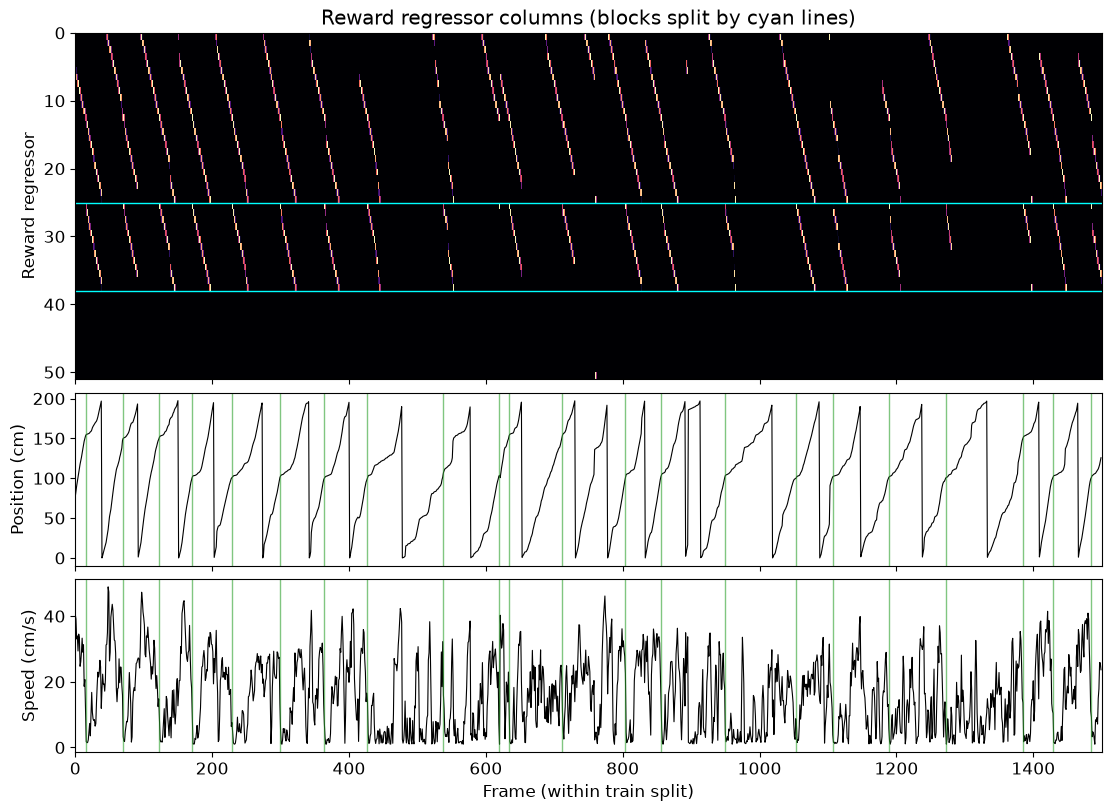

In [4]:
def plot_reward_regressors(bundle, start=0, num_frames=1500):
    frames = slice(start, start + num_frames)
    data = bundle["train"]
    frame_behavior = data["frame_behavior"]
    slices = bundle["block_slices"]
    reward_columns = _columns_of(slices, REWARD_BLOCKS)
    reward = data["regressors"][frames][:, reward_columns]

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, height_ratios=[2, 1, 1], layout="constrained")

    axes[0].imshow(reward.T, aspect="auto", interpolation="nearest", cmap="magma",
                   extent=[0, reward.shape[0], reward.shape[1], 0])
    boundary = 0
    for name in REWARD_BLOCKS[:-1]:
        boundary += slices[name].stop - slices[name].start
        axes[0].axhline(boundary, color="cyan", linewidth=1)
    axes[0].set_ylabel("Reward regressor")
    axes[0].set_title("Reward regressor columns (blocks split by cyan lines)")

    axes[1].plot(frame_behavior.position[frames], color="k", linewidth=0.8)
    axes[1].set_ylabel("Position (cm)")

    axes[2].plot(frame_behavior.speed[frames], color="k", linewidth=0.8)
    axes[2].set_ylabel("Speed (cm/s)")
    axes[2].set_xlabel("Frame (within train split)")

    for ax in axes[1:]:
        for idx in np.where(frame_behavior.reward_delivery[frames])[0]:
            ax.axvline(idx, color="tab:green", alpha=0.6, linewidth=1)
        for idx in np.where(frame_behavior.reward_omitted[frames])[0]:
            ax.axvline(idx, color="tab:red", alpha=0.6, linewidth=1)
    return fig


plot_reward_regressors(bundle)
plt.show()

## 3. Does the speed filter delete the reward response?

`PopulationRegistry._make_population` keeps only frames with `speed >= 1 cm/s`. If retention collapses in the
frames right after reward — where the mouse slows to lick — the model structurally cannot see a reward response,
and hypothesis 3 alone explains the result.

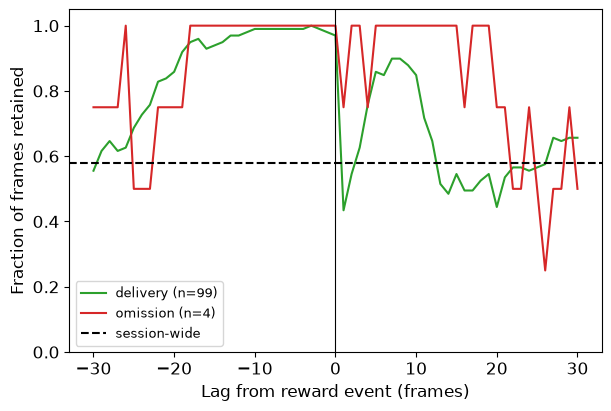

session-wide retention: 0.580
  delivery retention at lag  0: 0.970
  delivery retention at lag  5: 0.859
  delivery retention at lag 10: 0.848
  delivery retention at lag 20: 0.444
  delivery retention at lag 30: 0.657

reward events: 99 delivered, 4 omitted
  The omission block cannot be estimated or predicted; treat its scores as meaningless.


In [5]:
retention = reward_frame_retention(session, registry)

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot(retention["lags"], retention["delivery"], color="tab:green", label=f"delivery (n={retention['n_delivery']})")
ax.plot(retention["lags"], retention["omission"], color="tab:red", label=f"omission (n={retention['n_omission']})")
ax.axhline(retention["overall_retention"], color="k", linestyle="--", label="session-wide")
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Lag from reward event (frames)")
ax.set_ylabel("Fraction of frames retained")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.show()

print(f"session-wide retention: {retention['overall_retention']:.3f}")
for lag in (0, 5, 10, 20, 30):
    value = retention["delivery"][retention["lags"] == lag][0]
    print(f"  delivery retention at lag {lag:>2}: {value:.3f}")
print()
print(f"reward events: {retention['n_delivery']} delivered, {retention['n_omission']} omitted")
if retention["n_omission"] < 10:
    reward_omission_width = block_slices["reward_omission"].stop - block_slices["reward_omission"].start
    print(f"  WARNING: {reward_omission_width} omission regressors are being fit to {retention['n_omission']} events.")
    print("  The omission block cannot be estimated or predicted; treat its scores as meaningless.")

## 4. Regressor scale, sparsity and collinearity

- **High** `r2_from_pos_speed` for reward columns ⇒ reward is redundant with position/speed, and the RRR result
  becomes self-contradictory (redundant columns should be *easy* to predict).
- **Low** ⇒ the reward columns carry unique variance that the population simply doesn't track.

The scale/sparsity panel matters because R² on a near-zero, near-delta signal is dominated by a handful of frames.

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


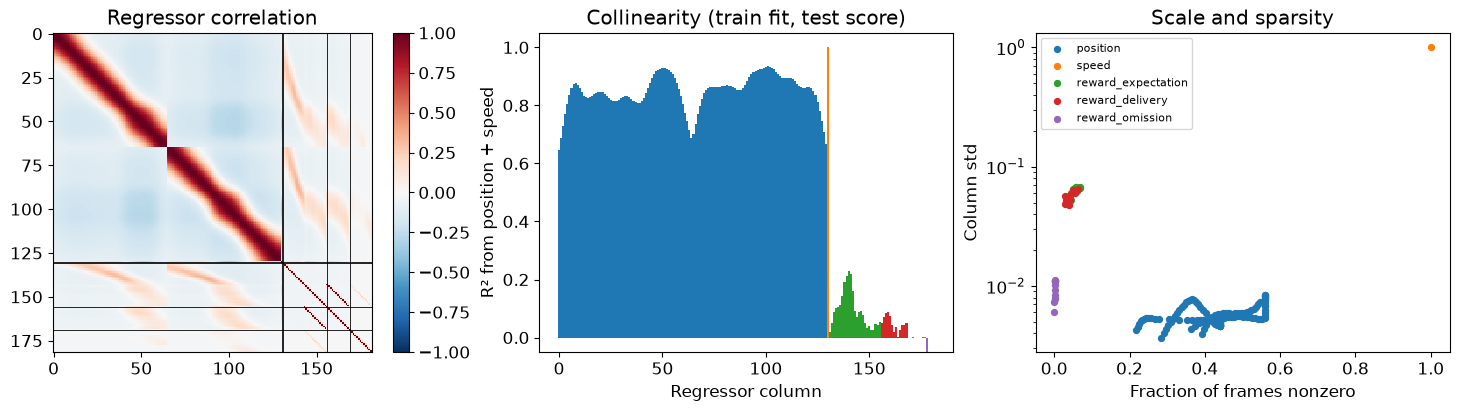

                        mean       min       max
block                                           
position            0.849362  0.647324  0.934621
reward_delivery     0.048293  0.002520  0.087877
reward_expectation  0.094940  0.018715  0.230879
reward_omission    -0.337405 -4.392216  0.002579
speed               1.000000  1.000000  1.000000

                         std  fraction_nonzero     kurtosis
block                                                      
position            0.005660          0.424719     6.604454
reward_delivery     0.054451          0.039497    45.284859
reward_expectation  0.059480          0.048883    36.804428
reward_omission     0.009490          0.001231  1936.249390
speed               0.999999          1.000000    -1.020428


In [6]:
stats = regressor_stats(bundle)
collinearity = regressor_collinearity(bundle)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")

corr = np.corrcoef(bundle["train"]["regressors"], rowvar=False)
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
boundary = 0
for name in BLOCK_NAMES[:-1]:
    boundary += block_slices[name].stop - block_slices[name].start
    axes[0].axhline(boundary, color="k", linewidth=0.6)
    axes[0].axvline(boundary, color="k", linewidth=0.6)
axes[0].set_title("Regressor correlation")
fig.colorbar(im, ax=axes[0], fraction=0.046)

colors = dict(zip(BLOCK_NAMES, plt.cm.tab10(np.arange(len(BLOCK_NAMES)))))
axes[1].bar(collinearity["column"], collinearity["r2_from_pos_speed"],
            color=[colors[b] for b in collinearity["block"]], width=1.0)
axes[1].set_xlabel("Regressor column")
axes[1].set_ylabel("R² from position + speed")
axes[1].set_title("Collinearity (train fit, test score)")
axes[1].set_ylim(-0.05, 1.05)

for name in BLOCK_NAMES:
    sub = stats[stats["block"] == name]
    axes[2].scatter(sub["fraction_nonzero"], sub["std"], s=18, color=colors[name], label=name)
axes[2].set_xlabel("Fraction of frames nonzero")
axes[2].set_ylabel("Column std")
axes[2].set_yscale("log")
axes[2].legend(fontsize=8)
axes[2].set_title("Scale and sparsity")
plt.show()

print(collinearity.groupby("block")["r2_from_pos_speed"].describe()[["mean", "min", "max"]])
print()
print(stats.groupby("block")[["std", "fraction_nonzero", "kurtosis"]].mean())

## 5. Can activity predict the basis, per column?

`fullregressor_decoder_only_1dspeed` has no encoder — its decoder is fed the true, behavior-derived basis. So we
fit the equivalent map ourselves: source activity → true basis, trained on `train`, one global alpha chosen on
`validation`, scored per column on `test`.

That is the right question anyway. A `_leak` model's encoder is trained on the same split as its decoder, which
lets its basis act as a generic rank channel between source and target activity rather than as an estimate of the
external variables. Fitting the map ourselves keeps it honest.

Position high and reward near zero would pin the RRR result to specific columns.

encoder alpha selected on validation: 10


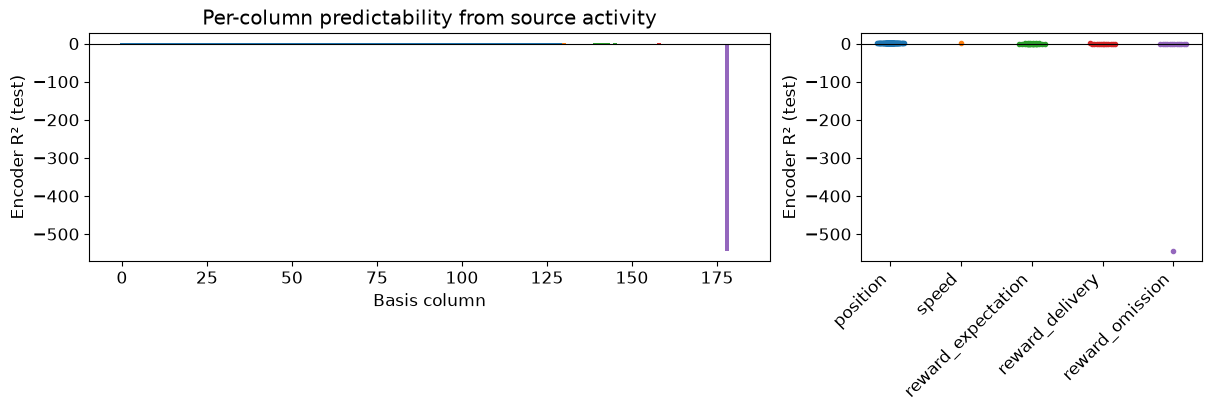

                         mean    median       max
block                                            
position             0.710436  0.698191  0.903506
reward_delivery      0.021351 -0.001548  0.274312
reward_expectation   0.094714  0.041709  0.372516
reward_omission    -41.835674 -0.014303  0.000000
speed                0.300591  0.300591  0.300591


In [7]:
predictability = fit_basis_encoder(session, bundle)
print(f"encoder alpha selected on validation: {predictability['alpha'].iloc[0]:g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[2, 1], layout="constrained")

axes[0].bar(predictability["column"], predictability["r2_encoder"],
            color=[colors[b] for b in predictability["block"]], width=1.0)
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set_xlabel("Basis column")
axes[0].set_ylabel("Encoder R² (test)")
axes[0].set_title("Per-column predictability from source activity")

order = [b for b in BLOCK_NAMES]
for i, name in enumerate(order):
    values = predictability.loc[predictability["block"] == name, "r2_encoder"].to_numpy()
    axes[1].plot(i + 0.2 * beeswarm(values), values, ".", color=colors[name], markersize=6)
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set_xticks(range(len(order)), order, rotation=45, ha="right")
axes[1].set_ylabel("Encoder R² (test)")
plt.show()

print(predictability.groupby("block")["r2_encoder"].agg(["mean", "median", "max"]))

## 5.1 Is it temporal precision? Sweep the reward basis shape

The reward basis is raised-cosine in **time**; the position basis is Gaussian in **space**. Running speed varies, so
a fixed-width time kernel covers a variable spatial extent and aligns with no fixed spatial basis function. The
optimized basis is also sharp — `reward_basis_width ≈ 1.6` frames — while calcium activity is temporally smeared.

Refit the encoder over a grid of `(reward_num_basis_lags, reward_basis_width)` and re-score. Two knobs are
confounded in that grid and separated in the panels below:

- **kernel width** — how sharply each column is localized in time (the precision hypothesis)
- **total support** — `lags × width`, how far from the reward the basis reaches (the speed-filter hypothesis of §3)

If R² climbs steeply with width, the reward basis is simply asking for more temporal precision than the population
has, and a coarser basis fixes it. If it stays flat near 0.1, there is no reward-specific signal to find.

Each block gets the alpha that maximizes **its own** validation R² — a deliberately generous test, so a flat result
cannot be blamed on a shared ridge penalty tuned for position. Runtime is a few minutes (one SVD, reused).

In [8]:
def _augment(X: torch.Tensor) -> torch.Tensor:
    """Append the intercept column, matching ``RidgeRegression._add_intercept``."""
    return torch.cat([X, torch.ones(X.size(0), 1, dtype=X.dtype)], dim=1)


def _ridge_beta_from_svd(svd, UTy: torch.Tensor, alpha: float) -> torch.Tensor:
    """Ridge solution from a precomputed SVD: ``beta = V diag(s / (s^2 + alpha)) U^T y``.

    This is the SVD branch of ``dimilibi.RidgeRegression._solve_ols_ridge``, split so that
    ``U^T y`` is computed once per target matrix and reused across alphas — the alpha loop is
    then the cheap part. ``reward_basis_sweep`` asserts it matches ``RidgeRegression.fit``.

    Parameters
    ----------
    svd : tuple of torch.Tensor
        ``(U, s, Vt)`` from ``RidgeRegression.compute_svd`` on the intercept-augmented design.
    UTy : torch.Tensor
        Precomputed ``U.T @ Y``.
    alpha : float
        Ridge penalty.

    Returns
    -------
    torch.Tensor
        Coefficients, shape (num_features + 1, num_targets).
    """
    _, s, Vt = svd
    d = torch.where(s > 1e-15, s / (s**2 + alpha), torch.zeros_like(s))
    return Vt.T @ (d[:, None] * UTy)


def reward_basis_sweep(
    session,
    bundle: dict,
    lags_values=(1, 3, 7, 13),
    width_values=(1.6, 3.0, 6.0, 12.0, 24.0),
    alphas=(1.0, 10.0, 100.0, 1e3, 1e4),
    validate: bool = True,
) -> pd.DataFrame:
    """Encoder R^2 per regressor block over a grid of reward temporal-basis shapes.

    The encoder design matrix (source activity) is fixed across the whole grid, so its SVD is
    computed once and reused for every (lags, width, alpha) fit. Only the regressor targets
    change. Predictions apply the same ReLU the real encoder uses (``model.nonnegative``).

    Each block's reported test R^2 uses the alpha that maximized that block's *validation* R^2,
    so no block is penalized by a shared penalty tuned for another.

    Parameters
    ----------
    session : B2Session
        Session to analyze.
    bundle : dict
        Output of :func:`build_reward_bundle`; supplies the model, spks_type, and the baseline
        hyperparameters that every grid point is derived from via ``dataclasses.replace``.
    lags_values : iterable of int
        ``reward_num_basis_lags`` values to sweep.
    width_values : iterable of float
        ``reward_basis_width`` values to sweep, in imaging frames.
    alphas : iterable of float
        Encoder ridge penalties searched at each grid point.
    validate : bool
        If True, assert the fast SVD solve reproduces ``RidgeRegression.fit`` on the first point.

    Returns
    -------
    pandas.DataFrame
        One row per (lags, width, block): ``num_columns``, ``support`` (lags * width), the
        selected ``alpha``, ``r2_val`` / ``r2_test``, and ``r2_from_pos_speed`` — the
        regressor-only control (no neural data) needed to tell "the population encodes reward"
        apart from "this reward basis is just a smooth function of position".
    """
    model, hyperparameters_0, spks_type = bundle["model"], bundle["hyperparameters"], bundle["spks_type"]

    # Source activity is fixed across the grid, so build it once from the baseline shape and reuse
    # its SVD; only the regressor targets are rebuilt per grid point.
    baseline = encoder_data(session, model, hyperparameters_0, spks_type)
    splits = {split: (baseline[split]["X"], baseline[split]["frame_behavior"]) for split in baseline}

    svd = RidgeRegression(alpha=1.0, fit_intercept=True).compute_svd(splits["train"][0])
    U = svd[0]
    augmented = {split: _augment(X) for split, (X, _) in splits.items()}

    rows = []
    checked = False
    for lags in lags_values:
        for width in width_values:
            hyperparameters = replace(hyperparameters_0, reward_num_basis_lags=int(lags), reward_basis_width=float(width))
            blocks, targets = {}, {}
            for split, (_, frame_behavior) in splits.items():
                split_blocks = [np.asarray(b) for b in model.build_regressors(session, frame_behavior, hyperparameters, as_list=True)]
                blocks[split] = split_blocks
                targets[split] = _tt(np.concatenate(split_blocks, axis=1))
            slices = _block_slices(blocks["train"])

            UTy = U.T @ targets["train"]
            best: dict[str, tuple[float, float, float]] = {}
            for alpha in alphas:
                beta = _ridge_beta_from_svd(svd, UTy, alpha)
                if validate and not checked:
                    reference = RidgeRegression(alpha=alpha, fit_intercept=True).fit(splits["train"][0], targets["train"])
                    assert torch.allclose(beta, reference._beta_ols, atol=1e-3), "fast SVD solve diverges from RidgeRegression.fit"
                    checked = True
                scores = {}
                for split in ("validation", "test"):
                    prediction = torch.relu(augmented[split] @ beta)  # model.nonnegative is True
                    scores[split] = measure_r2(prediction, targets[split], dim=0, reduce="none").numpy()
                for name, sl in slices.items():
                    r2_val, r2_test = float(np.nanmean(scores["validation"][sl])), float(np.nanmean(scores["test"][sl]))
                    if name not in best or r2_val > best[name][1]:
                        best[name] = (alpha, r2_val, r2_test)

            # Regressor-only control: how much of each block is recoverable from the position and
            # speed columns alone. Reward sits at a fixed track position, so a coarse reward-time
            # basis can be a smooth function of position and would be "predictable" for reasons
            # that have nothing to do with reward coding.
            idx_nonreward = _columns_of(slices, NONREWARD_BLOCKS)
            collinear_fit = RidgeRegression(alpha=1.0, fit_intercept=True).fit(
                targets["train"][:, idx_nonreward], targets["train"]
            )
            r2_collinear = collinear_fit.score(targets["test"][:, idx_nonreward], targets["test"], dim=0, reduce="none").numpy()

            for name, (alpha, r2_val, r2_test) in best.items():
                rows.append(
                    dict(
                        lags=int(lags),
                        width=float(width),
                        block=name,
                        num_columns=slices[name].stop - slices[name].start,
                        support=float(lags) * float(width),
                        alpha=alpha,
                        r2_val=r2_val,
                        r2_test=r2_test,
                        r2_from_pos_speed=float(np.nanmean(r2_collinear[slices[name]])),
                    )
                )
    return pd.DataFrame(rows)

In [9]:
sweep = reward_basis_sweep(session, bundle)
print(f"{len(sweep)} rows | {sweep['block'].nunique()} blocks x {sweep[['lags', 'width']].drop_duplicates().shape[0]} grid points")
sweep.groupby("block")["r2_test"].agg(["min", "max"])

100 rows | 5 blocks x 20 grid points


,min,max
block,,
position,0.710436,0.710436
reward_delivery,0.055563,0.523584
reward_expectation,0.096600,0.610519
reward_omission,-0.065483,0.167758
speed,0.300591,0.300591


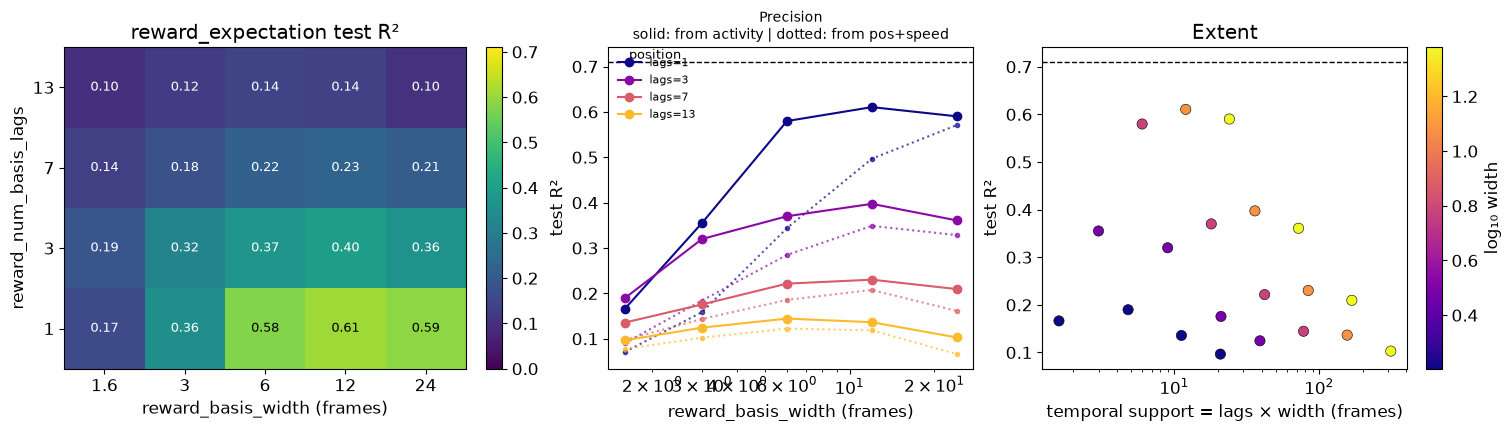

position reference R²      : 0.710
baseline (optimized) point : lags=12, width=2.23
best reward_expectation : lags=1, width=12 -> R²=0.611

--- reward_expectation test R² from activity (rows=lags, cols=width) ---
width   1.6    3.0    6.0    12.0   24.0
lags                                    
1      0.166  0.355  0.580  0.611  0.590
3      0.190  0.320  0.370  0.397  0.361
7      0.136  0.176  0.222  0.230  0.210
13     0.097  0.125  0.145  0.136  0.103

--- reward_expectation test R² from position+speed regressors only (control) ---
width   1.6    3.0    6.0    12.0   24.0
lags                                    
1      0.071  0.159  0.344  0.497  0.571
3      0.091  0.184  0.285  0.349  0.328
7      0.097  0.144  0.186  0.208  0.161
13     0.078  0.102  0.122  0.119  0.066


In [10]:
SWEEP_BLOCK = "reward_expectation"  # the symmetric block; the one a single-basis model would keep

grid = sweep[sweep["block"] == SWEEP_BLOCK].pivot(index="lags", columns="width", values="r2_test")
position_reference = sweep.loc[sweep["block"] == "position", "r2_test"].mean()
baseline = (bundle["hyperparameters"].reward_num_basis_lags, bundle["hyperparameters"].reward_basis_width)

fig = plt.figure(figsize=(15, 4.2), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 1])

# --- A: (lags x width) heatmap, annotated -------------------------------------------------
ax = fig.add_subplot(gs[0])
norm = Normalize(vmin=0, vmax=max(position_reference, np.nanmax(grid.to_numpy())))
im = ax.imshow(grid.to_numpy(), cmap="viridis", norm=norm, aspect="auto", origin="lower")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        value = grid.to_numpy()[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="w" if norm(value) < 0.6 else "k")
ax.set_xticks(range(grid.shape[1]), [f"{w:g}" for w in grid.columns])
ax.set_yticks(range(grid.shape[0]), [str(v) for v in grid.index])
ax.set_xlabel("reward_basis_width (frames)")
ax.set_ylabel("reward_num_basis_lags")
ax.set_title(f"{SWEEP_BLOCK} test R²")
fig.colorbar(im, ax=ax, fraction=0.046)

# Mark the optimizer's choice.
if baseline[0] in list(grid.index):
    ax.plot(np.argmin(np.abs(np.array(grid.columns) - baseline[1])), list(grid.index).index(baseline[0]),
            marker="s", markersize=16, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

# --- B: R² vs kernel width, one line per lags. Dashed = regressor-only control -------------
grid_collinear = sweep[sweep["block"] == SWEEP_BLOCK].pivot(index="lags", columns="width", values="r2_from_pos_speed")
ax = fig.add_subplot(gs[1])
for lags, color in zip(grid.index, plt.cm.plasma(np.linspace(0, 0.85, len(grid.index)))):
    ax.plot(grid.columns, grid.loc[lags], "o-", color=color, label=f"lags={lags}")
    ax.plot(grid_collinear.columns, grid_collinear.loc[lags], "o:", color=color, markersize=3, alpha=0.7)
ax.axhline(position_reference, color="k", linestyle="--", linewidth=1)
ax.text(grid.columns[0], position_reference, " position", va="bottom", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("reward_basis_width (frames)")
ax.set_ylabel("test R²")
ax.set_title("Precision\nsolid: from activity | dotted: from pos+speed", fontsize=10)
ax.legend(fontsize=8, frameon=False)

# --- C: R² vs total temporal support ------------------------------------------------------
ax = fig.add_subplot(gs[2])
sub = sweep[sweep["block"] == SWEEP_BLOCK]
scatter = ax.scatter(sub["support"], sub["r2_test"], c=np.log10(sub["width"]), cmap="plasma", s=55, edgecolor="k", linewidth=0.4)
ax.axhline(position_reference, color="k", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("temporal support = lags × width (frames)")
ax.set_ylabel("test R²")
ax.set_title("Extent")
fig.colorbar(scatter, ax=ax, fraction=0.046, label="log₁₀ width")

plt.show()

print(f"position reference R²      : {position_reference:.3f}")
print(f"baseline (optimized) point : lags={baseline[0]}, width={baseline[1]:.2f}")
best_row = sub.loc[sub["r2_test"].idxmax()]
print(f"best {SWEEP_BLOCK:19}: lags={best_row['lags']}, width={best_row['width']:g} -> R²={best_row['r2_test']:.3f}")
print()
print(f"--- {SWEEP_BLOCK} test R² from activity (rows=lags, cols=width) ---")
print(grid.round(3).to_string())
print()
print(f"--- {SWEEP_BLOCK} test R² from position+speed regressors only (control) ---")
print(grid_collinear.round(3).to_string())

### 5.1 result — precision matters, but the control is confounded

R² climbs steeply as the kernel widens: ~0.10 near the optimized shape `(lags=12, width=2.2)` up to **0.611** at
`(lags=1, width=12)`. Still below the position reference of **0.710**, but a 6x change from basis shape alone.

The dotted control — predicting the same reward columns from the position and speed regressors, **no neural
data** — sits below the activity curve at coarse settings:

| (lags, width) | from activity | from pos+speed only |
|---|---|---|
| 13, 1.6 | 0.097 | 0.078 |
| 7, 3 | 0.176 | 0.144 |
| 1, 6 | 0.580 | 0.344 |
| 1, 12 | 0.611 | 0.497 |
| 1, 24 | 0.590 | 0.571 |

So activity does carry something beyond these position regressors. **But the comparison is confounded**: the
control's power depends on how expressive the position basis is, and that is itself an optimized hyperparameter.
This model chose `num_basis=65` with `basis_width=17.2` — many bumps, but very wide and smooth ones, which cannot
represent a sharp reward-time bump. Under the leak model's finer basis (`31 x 4.68`) the same control tracked the
activity curve almost exactly.

The gap above is therefore an upper bound on reward-specific information, not a measurement of it. A fair test
needs the control given a maximally expressive position basis rather than the decoder's chosen one. What survives
cleanly: at the *optimized* reward shape both curves are low (~0.10), so whatever the population knows about
reward timing at that resolution, it is little, and most of it is also in position and speed.

## 5.2 What does the optimizer pick, cohort-wide? A natural experiment

This is the decisive test of the **rank-channel** hypothesis.

In a `_leak` model the basis sits between source and target activity as a bottleneck, and both maps are linear.
Adding reward columns therefore raises the rank of the composite source→target map — which genuinely improves
held-out prediction — regardless of whether those columns represent reward. `num_reward_columns = 4L + 3`, so more
lags buys more rank; and narrower kernels overlap less, so each column buys *independent* rank. Prediction:
**max lags, min width**.

The decoder-only model has no bottleneck — its decoder is fed the true basis directly. There is no rank to buy,
so extra reward columns should be worth nothing and the optimizer should show no such march.

Same data, same splits, same reward search space, only the bottleneck differs. Overlaid is the Optuna **search
space** from `FullRegressorHyperparameters.get_optuna_space`: `lags ~ U{1..15}`, `width ~ U[1, 35/(lags+1)]`,
support capped at 35 frames. TPE is not a uniform sampler, so agreement with that reference means "no consistent
preference across sessions" rather than literally "sampled at random".

Reads cached hyperparameters only. Sessions with no cache are skipped rather than triggering a fresh Optuna run.

In [11]:
# Search space literals from FullRegressorHyperparameters.get_optuna_space (not exported, so mirrored here).
OPTUNA_MAX_REWARD_SUPPORT = 35
OPTUNA_LAGS_RANGE = (1, 15)
OPTUNA_MIN_REWARD_WIDTH = 1.0


def reward_hyperparameter_survey(
    sessions,
    registry,
    model_name: str = EXTERNAL_MODEL_NAME,
    spks_type: str = EXAMPLE_SPKS_TYPE,
    activity_parameters_name: str = ACTIVITY_PARAMETERS_NAME,
    method: str = HYPERPARAMETER_METHOD,
) -> pd.DataFrame:
    """Cached best hyperparameters for a regression model across many sessions.

    Only reads the hyperparameter cache. ``get_best_hyperparameters`` silently runs a full
    optimization when no cache exists, so the cache path is checked first and uncached sessions
    are skipped.

    Parameters
    ----------
    sessions : list of B2Session
        Sessions to survey.
    registry : PopulationRegistry
        Supplies the hyperparameter cache directory (and the registry hash in the cache key).
    model_name : str
        Registry model name to survey.
    spks_type : str
        Spike type the hyperparameters were optimized for.
    activity_parameters_name : str
        Activity scaling preset.
    method : str
        Optimization method; "preferred" resolves to the model's own preferred method.

    Returns
    -------
    pandas.DataFrame
        One row per cached session: identifiers, the reward hyperparameters, derived ``support``
        (lags * width) and ``num_reward_columns`` (4L + 3), plus the position and alpha
        hyperparameters for context, and the ``model`` the row came from.
    """
    model = get_model(model_name, registry, activity_parameters=activity_parameters_name)
    resolved_method = model._resolve_optimization_method(method)

    rows, missing = [], 0
    for session in sessions:
        cache_key = model._get_hyperparameter_cache_key(session, spks_type, "train", "validation", resolved_method)
        if not (registry.registry_paths.hyperparameter_path / f"{cache_key}.joblib").exists():
            missing += 1
            continue
        hyperparameters = model.get_best_hyperparameters(session, spks_type=spks_type, method=method)[0]
        rows.append(
            dict(
                model=model_name,
                session=session.session_uid,
                mouse=session.mouse_name,
                reward_num_basis_lags=hyperparameters.reward_num_basis_lags,
                reward_basis_width=hyperparameters.reward_basis_width,
                support=hyperparameters.reward_num_basis_lags * hyperparameters.reward_basis_width,
                num_reward_columns=4 * hyperparameters.reward_num_basis_lags + 3,
                num_basis=hyperparameters.num_basis,
                basis_width=hyperparameters.basis_width,
                alpha_encoder=hyperparameters.alpha_encoder,
                alpha_decoder=hyperparameters.alpha_decoder,
            )
        )
    print(f"{model_name}: {len(rows)} cached, {missing} skipped (no cache)")
    return pd.DataFrame(rows)


def sample_reward_search_space(num_samples: int, seed: int = 0) -> pd.DataFrame:
    """Draw uniformly from the Optuna reward search space, as a reference distribution.

    Parameters
    ----------
    num_samples : int
        Number of draws.
    seed : int
        RNG seed.

    Returns
    -------
    pandas.DataFrame
        Columns ``reward_num_basis_lags``, ``reward_basis_width``, ``support``.
    """
    rng = np.random.default_rng(seed)
    lags = rng.integers(OPTUNA_LAGS_RANGE[0], OPTUNA_LAGS_RANGE[1] + 1, size=num_samples)
    width = rng.uniform(OPTUNA_MIN_REWARD_WIDTH, OPTUNA_MAX_REWARD_SUPPORT / (lags + 1))
    return pd.DataFrame({"reward_num_basis_lags": lags, "reward_basis_width": width, "support": lags * width})

In [12]:
LEAK_MODEL_NAME = "fullregressor_leak_1dspeed"  # the bottleneck model, for contrast only

all_sessions = get_database("vrSessions").iter_sessions(imaging=True)
survey = reward_hyperparameter_survey(all_sessions, registry)
survey_leak = reward_hyperparameter_survey(all_sessions, registry, model_name=LEAK_MODEL_NAME)
reference = sample_reward_search_space(20000)

SURVEYS = {"decoder-only (no bottleneck)": survey, "leak (bottleneck)": survey_leak}
SURVEY_COLORS = {"decoder-only (no bottleneck)": "#000000", "leak (bottleneck)": "#c00000"}

fullregressor_decoder_only_1dspeed: 149 cached, 0 skipped (no cache)
fullregressor_leak_1dspeed: 149 cached, 0 skipped (no cache)


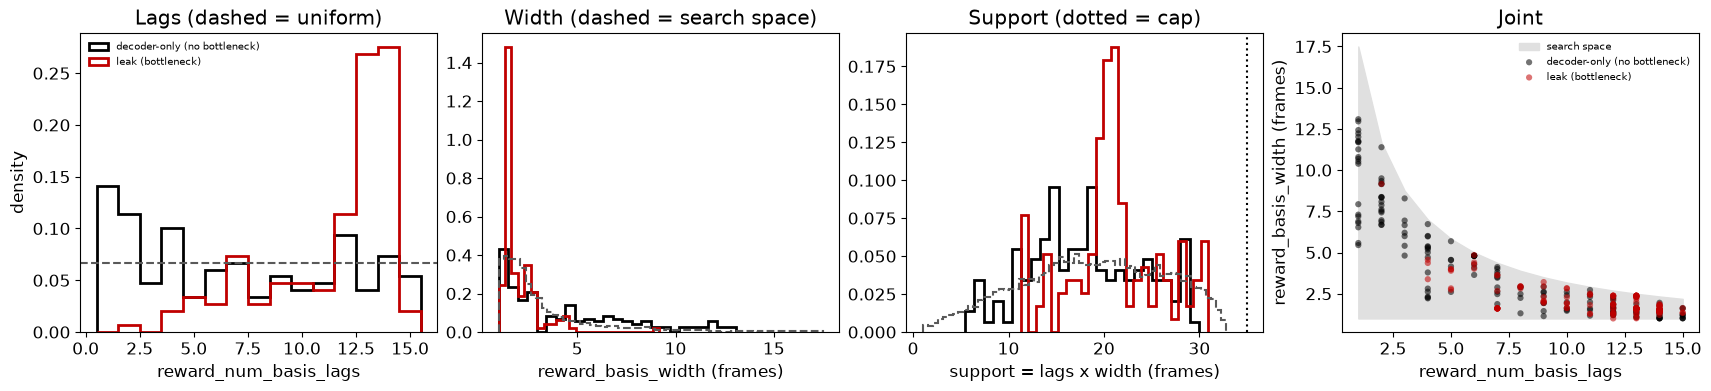

model                  decoder-only (no bottleneck)  leak (bottleneck)
n                                           149.000            149.000
lags_median                                   7.000             13.000
lags_mean                                     7.074             11.503
lags_std                                      4.705              2.977
width_median                                  2.927              1.615
frac_sharp                                    0.503              0.906
support_median                               17.649             20.832
reward_columns_median                        31.000             55.000
KS_lags                                       0.134              0.412
KS_basis_width                                0.231              0.318
KS_support                                    0.108              0.274

--- decoder-only (no bottleneck) ---
  KS vs search space | reward_num_basis_lags  D=0.134  p=0.00892
  KS vs search space | reward_basis_width    

In [13]:
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), layout="constrained")
reference_kwargs = dict(color="0.35", linewidth=1.5)

# --- A: lags ------------------------------------------------------------------------------
bins = np.arange(OPTUNA_LAGS_RANGE[0], OPTUNA_LAGS_RANGE[1] + 2) - 0.5
for label, frame in SURVEYS.items():
    axes[0].hist(frame["reward_num_basis_lags"], bins=bins, density=True, histtype="step",
                 linewidth=2, color=SURVEY_COLORS[label], label=label)
axes[0].axhline(1 / (OPTUNA_LAGS_RANGE[1] - OPTUNA_LAGS_RANGE[0] + 1), linestyle="--", **reference_kwargs)
axes[0].set_xlabel("reward_num_basis_lags")
axes[0].set_ylabel("density")
axes[0].set_title("Lags (dashed = uniform)")
axes[0].legend(fontsize=7, frameon=False)

# --- B: width -----------------------------------------------------------------------------
for label, frame in SURVEYS.items():
    axes[1].hist(frame["reward_basis_width"], bins=25, density=True, histtype="step",
                 linewidth=2, color=SURVEY_COLORS[label])
axes[1].hist(reference["reward_basis_width"], bins=60, density=True, histtype="step", linestyle="--", **reference_kwargs)
axes[1].set_xlabel("reward_basis_width (frames)")
axes[1].set_title("Width (dashed = search space)")

# --- C: total support ---------------------------------------------------------------------
for label, frame in SURVEYS.items():
    axes[2].hist(frame["support"], bins=25, density=True, histtype="step",
                 linewidth=2, color=SURVEY_COLORS[label])
axes[2].hist(reference["support"], bins=60, density=True, histtype="step", linestyle="--", **reference_kwargs)
axes[2].axvline(OPTUNA_MAX_REWARD_SUPPORT, color="k", linestyle=":", linewidth=1.5)
axes[2].set_xlabel("support = lags x width (frames)")
axes[2].set_title("Support (dotted = cap)")

# --- D: joint, against the search-space boundary ------------------------------------------
lag_grid = np.arange(OPTUNA_LAGS_RANGE[0], OPTUNA_LAGS_RANGE[1] + 1)
axes[3].fill_between(lag_grid, OPTUNA_MIN_REWARD_WIDTH, OPTUNA_MAX_REWARD_SUPPORT / (lag_grid + 1),
                     color="0.88", label="search space")
for label, frame in SURVEYS.items():
    axes[3].scatter(frame["reward_num_basis_lags"], frame["reward_basis_width"], s=20,
                    color=SURVEY_COLORS[label], edgecolor="none", alpha=0.55, zorder=3, label=label)
axes[3].set_xlabel("reward_num_basis_lags")
axes[3].set_ylabel("reward_basis_width (frames)")
axes[3].set_title("Joint")
axes[3].legend(fontsize=7, frameon=False)

plt.show()

summary_rows = []
for label, frame in SURVEYS.items():
    row = dict(
        model=label,
        n=len(frame),
        lags_median=frame["reward_num_basis_lags"].median(),
        lags_mean=frame["reward_num_basis_lags"].mean(),
        lags_std=frame["reward_num_basis_lags"].std(),
        width_median=frame["reward_basis_width"].median(),
        frac_sharp=(frame["reward_basis_width"] < 3).mean(),
        support_median=frame["support"].median(),
        reward_columns_median=frame["num_reward_columns"].median(),
    )
    for column in ("reward_num_basis_lags", "reward_basis_width", "support"):
        row[f"KS_{column.replace('reward_', '').replace('num_basis_', '')}"] = ks_2samp(frame[column], reference[column]).statistic
    summary_rows.append(row)

print(pd.DataFrame(summary_rows).set_index("model").round(3).T.to_string())
print()
for label, frame in SURVEYS.items():
    print(f"--- {label} ---")
    for column in ("reward_num_basis_lags", "reward_basis_width", "support"):
        statistic, pvalue = ks_2samp(frame[column], reference[column])
        print(f"  KS vs search space | {column:22} D={statistic:.3f}  p={pvalue:.3g}")

### 5.2 result — the rank-channel hypothesis is confirmed

Both models have all 149 sessions cached. Same data, same splits, same reward search space:

| | decoder-only (no bottleneck) | leak (bottleneck) |
|---|---|---|
| lags median | **7** | **13** |
| lags mean +/- sd | 7.07 +/- 4.71 | 11.50 +/- 2.98 |
| width median | **2.93** | **1.62** |
| fraction width < 3 frames | **50.3%** | **90.6%** |
| support median | 17.6 | 20.8 |
| reward columns median | **31** | **55** |
| KS vs search space (lags) | 0.134, p=0.009 | **0.412, p=3e-23** |
| KS vs search space (width) | 0.231, p=2e-07 | 0.318, p=8e-14 |
| KS vs search space (support) | 0.108, **p=0.057** | 0.274, p=3e-10 |

Exactly the predicted dissociation. The leak model marches hard to the max-lags / min-width corner (lags median
at 13 of a possible 15, 91% of sessions below 3 frames, KS D=0.41). Remove the bottleneck and the march largely
disappears: lags median drops to 7 against a search-space mean of 8, the spread widens (sd 2.98 -> 4.71, i.e. no
consistent preference), support becomes statistically indistinguishable from the search space (p=0.057), and the
median session ends up with **31 reward columns instead of 55**.

The leak model was buying rank, not reward. Its basis sits between source and target activity, so extra
near-orthogonal reward columns raise the rank of the composite map and genuinely improve held-out prediction —
for reasons that have nothing to do with what the columns represent. That is why its reward latents were
unpredictable from RRR: they were never a reward representation in the first place.

A residual preference for sharp kernels survives in the decoder-only model (width KS D=0.231, p=2e-07), so
kernel width is doing *something* beyond rank. Lags and support are the knobs that were purely rank.

## 6. Reward-triggered averages

The model-independent question: are neurons tuned to reward at all? Four conditions — delivery vs omission ×
all frames vs speed-filtered frames — plus a place-field-residual variant that asks whether reward tuning
survives removing the spatial component. Neurons sorted by shuffle-z modulation; the null comes from circularly
shifted event times.

In [14]:
activity = rta_activity(session, registry, EXAMPLE_SPKS_TYPE)
residual = placefield_residual(session, registry, EXAMPLE_SPKS_TYPE)
frame_behavior_full = bundle["frame_behavior_full"]

rta_conditions = {}
for event_name, event_mask in (("delivery", frame_behavior_full.reward_delivery), ("omission", frame_behavior_full.reward_omitted)):
    for source_name, source in (("all frames", activity["all"]), ("speed-filtered", activity["filtered"]), ("PF residual", residual)):
        rta_conditions[(event_name, source_name)] = reward_triggered_average(source, event_mask)

print({key: value["num_events"] for key, value in rta_conditions.items()})

C:\Users\Andrew\AppData\Local\Temp\ipykernel_25356\397172148.py:406: RuntimeWarning: Mean of empty slice
  return np.nanmean(activity[idx], axis=0)  # (events, lags, rois) -> (lags, rois)


{('delivery', 'all frames'): 99, ('delivery', 'speed-filtered'): 99, ('delivery', 'PF residual'): 99, ('omission', 'all frames'): 4, ('omission', 'speed-filtered'): 4, ('omission', 'PF residual'): 4}


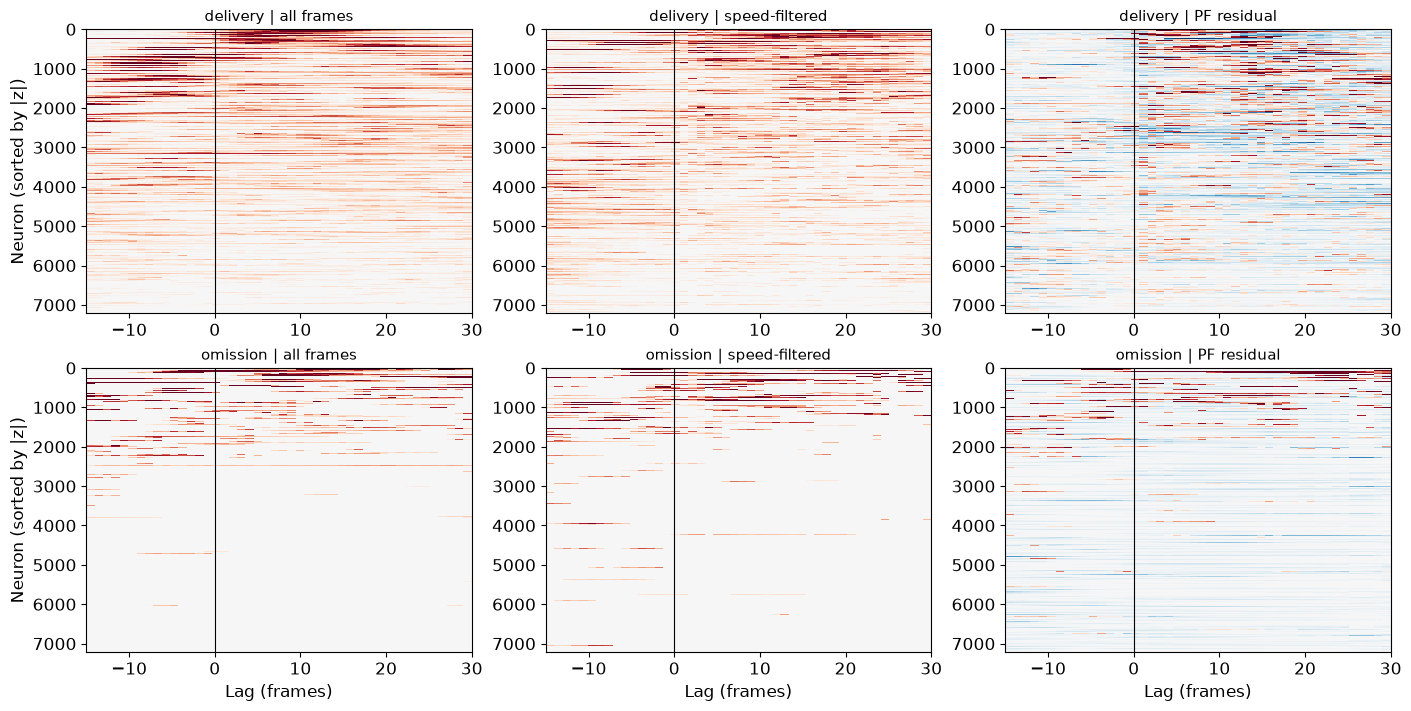

In [15]:
event_names = ["delivery", "omission"]
source_names = ["all frames", "speed-filtered", "PF residual"]

fig, axes = plt.subplots(len(event_names), len(source_names), figsize=(14, 7), layout="constrained")
for i, event_name in enumerate(event_names):
    for j, source_name in enumerate(source_names):
        result = rta_conditions[(event_name, source_name)]
        idx_sort = np.argsort(-np.nan_to_num(result["modulation_z"], nan=-np.inf))
        rta = result["rta"][:, idx_sort].T
        vmax = np.nanpercentile(np.abs(rta), 99)
        ax = axes[i, j]
        ax.imshow(rta, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest",
                  extent=[result["lags"][0], result["lags"][-1], rta.shape[0], 0])
        ax.axvline(0, color="k", linewidth=0.8)
        ax.set_title(f"{event_name} | {source_name}", fontsize=11)
        if i == len(event_names) - 1:
            ax.set_xlabel("Lag (frames)")
        if j == 0:
            ax.set_ylabel("Neuron (sorted by |z|)")
plt.show()

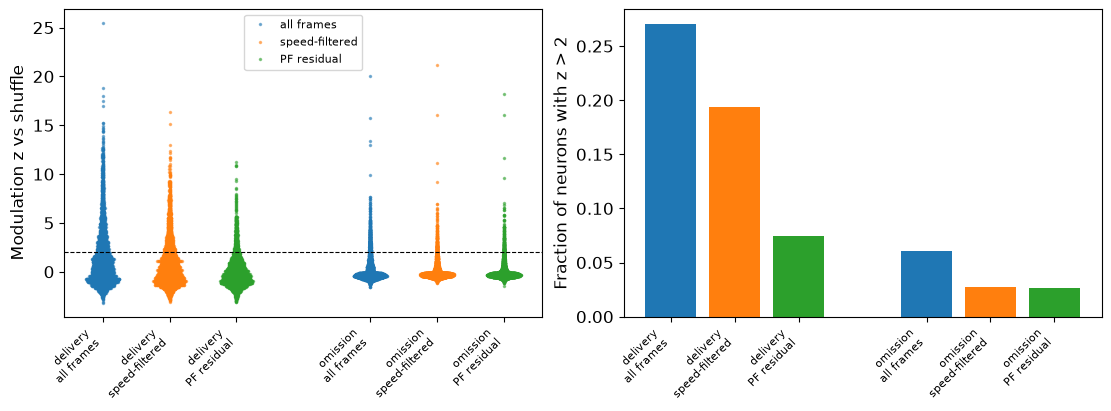

   event         source  num_events  fraction_z_above_2  median_z
delivery     all frames          99            0.270446  0.568526
delivery speed-filtered          99            0.192958  0.097570
delivery    PF residual          99            0.074300 -0.382923
omission     all frames           4            0.060715 -0.318359
omission speed-filtered           4            0.027585 -0.280962
omission    PF residual           4            0.026199 -0.292138


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

for i, event_name in enumerate(event_names):
    for j, source_name in enumerate(source_names):
        z = rta_conditions[(event_name, source_name)]["modulation_z"]
        z = z[np.isfinite(z)]
        position = i * (len(source_names) + 1) + j
        axes[0].plot(position + 0.25 * beeswarm(z), z, ".", markersize=3, alpha=0.5,
                     color=plt.cm.tab10(j), label=source_name if i == 0 else None)
        axes[1].bar(position, np.mean(z > 2), color=plt.cm.tab10(j))

ticks = [i * (len(source_names) + 1) + j for i in range(len(event_names)) for j in range(len(source_names))]
labels = [f"{e}\n{s}" for e in event_names for s in source_names]
for ax in axes:
    ax.set_xticks(ticks, labels, rotation=45, ha="right", fontsize=8)
axes[0].axhline(2, color="k", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Modulation z vs shuffle")
axes[1].set_ylabel("Fraction of neurons with z > 2")
axes[0].legend(fontsize=8)
plt.show()

summary = pd.DataFrame(
    [
        dict(
            event=event_name,
            source=source_name,
            num_events=rta_conditions[(event_name, source_name)]["num_events"],
            fraction_z_above_2=np.nanmean(rta_conditions[(event_name, source_name)]["modulation_z"] > 2),
            median_z=np.nanmedian(rta_conditions[(event_name, source_name)]["modulation_z"]),
        )
        for event_name in event_names
        for source_name in source_names
    ]
)
print(summary.to_string(index=False))

## 7. Decoder coefficients on the reward regressors

Is there structure in the reward coefficients, and how big is it relative to position? Amplitude is measured as
the temporal std of each block's partial prediction `X_block @ beta_block` — raw coefficient norms are not
comparable across blocks because the regressors differ in scale by orders of magnitude.

2026-07-23 15:10:30,226 [INFO] normalizing data across axis=1


2026-07-23 15:10:30,226 [INFO] projecting out mean along axis=0


2026-07-23 15:10:30,226 [INFO] data normalized, 0.00sec


2026-07-23 15:10:30,226 [INFO] sorting activity: 3564 valid samples by 51 timepoints


2026-07-23 15:10:30,384 [INFO] n_PCs = 51 computed, 0.16sec


C:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\rastermap\rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2026-07-23 15:10:30,857 [INFO] 100 clusters computed, time 0.63sec


2026-07-23 15:11:00,221 [INFO] clusters sorted, time 29.99sec


2026-07-23 15:11:00,363 [INFO] clusters upsampled, time 30.14sec


2026-07-23 15:11:00,367 [INFO] rastermap complete, time 30.14sec


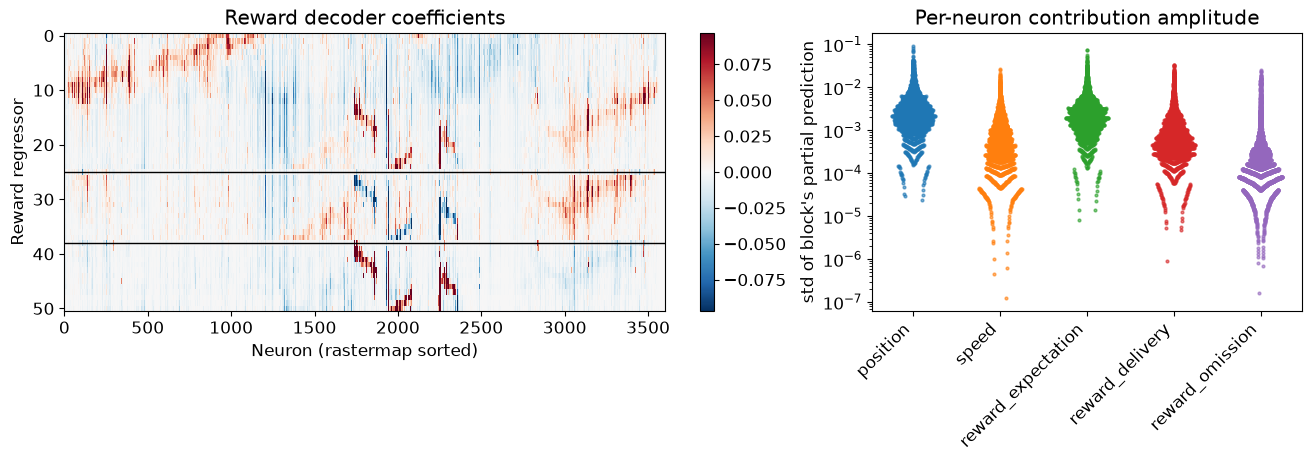

position              0.003782
speed                 0.001060
reward_expectation    0.003179
reward_delivery       0.001210
reward_omission       0.000243
dtype: float32


In [17]:
contributions = block_contributions(bundle)
beta = contributions["beta"]
reward_columns = _columns_of(block_slices, REWARD_BLOCKS)
reward_beta = beta[reward_columns]  # (reward columns, neurons)

idx_sort = Rastermap().fit(reward_beta.T).isort

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), width_ratios=[1.4, 1], layout="constrained")

vmax = np.percentile(np.abs(reward_beta), 99)
im = axes[0].imshow(reward_beta[:, idx_sort], aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, interpolation="nearest")
boundary = 0
for name in REWARD_BLOCKS[:-1]:
    boundary += block_slices[name].stop - block_slices[name].start
    axes[0].axhline(boundary, color="k", linewidth=1)
axes[0].set_xlabel("Neuron (rastermap sorted)")
axes[0].set_ylabel("Reward regressor")
axes[0].set_title("Reward decoder coefficients")
fig.colorbar(im, ax=axes[0], fraction=0.046)

for i, name in enumerate(BLOCK_NAMES):
    values = contributions["contribution_std"][name]
    axes[1].plot(i + 0.25 * beeswarm(values), values, ".", color=colors[name], markersize=4, alpha=0.6)
axes[1].set_yscale("log")
axes[1].set_xticks(range(len(BLOCK_NAMES)), BLOCK_NAMES, rotation=45, ha="right")
axes[1].set_ylabel("std of block's partial prediction")
axes[1].set_title("Per-neuron contribution amplitude")
plt.show()

print(pd.DataFrame({name: contributions["contribution_std"][name] for name in BLOCK_NAMES}).median())

## 8. Does reward buy anything at all?

Refit the decoder with and without the reward blocks. Because the model is decoder-only, this is exactly the
pathway its hyperparameter search optimizes — true basis → target activity — so ΔR² here is a faithful measure of
what the reward regressors are worth to the model itself.

A ΔR² near zero is direct evidence for hypothesis 1: the reward regressors are nuisance dimensions the optimizer
is free to shape arbitrarily, which would explain why nothing in the population predicts them.

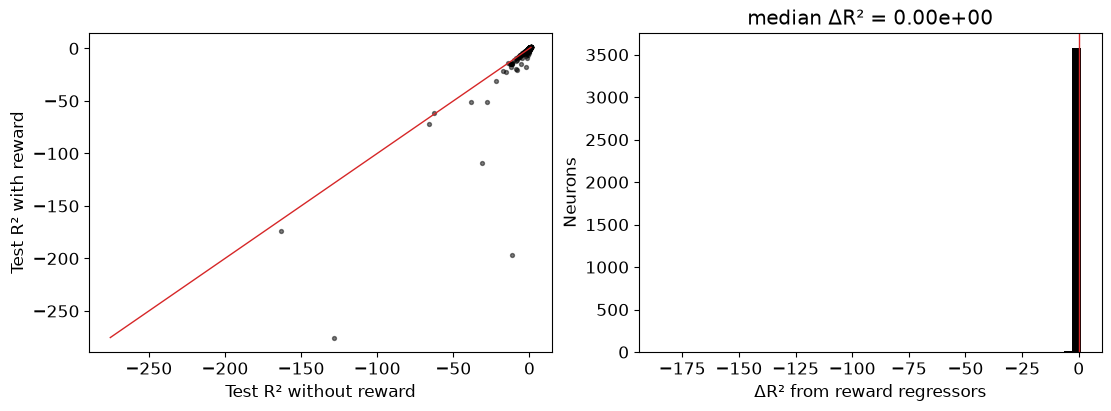

median R² full    : 0.0000
median R² ablated : 0.0000
median ΔR²        : 0.00e+00
neurons improved  : 0.236


In [18]:
ablation = reward_ablation(bundle)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

axes[0].scatter(ablation["r2_ablated"], ablation["r2_full"], s=8, alpha=0.5, color="k")
limits = [min(ablation["r2_ablated"].min(), ablation["r2_full"].min()), max(ablation["r2_ablated"].max(), ablation["r2_full"].max())]
axes[0].plot(limits, limits, color="tab:red", linewidth=1)
axes[0].set_xlabel("Test R² without reward")
axes[0].set_ylabel("Test R² with reward")

axes[1].hist(ablation["delta_r2"], bins=50, color="k")
axes[1].axvline(0, color="tab:red", linewidth=1)
axes[1].set_xlabel("ΔR² from reward regressors")
axes[1].set_ylabel("Neurons")
axes[1].set_title(f"median ΔR² = {np.median(ablation['delta_r2']):.2e}")
plt.show()

print(f"median R² full    : {np.median(ablation['r2_full']):.4f}")
print(f"median R² ablated : {np.median(ablation['r2_ablated']):.4f}")
print(f"median ΔR²        : {np.median(ablation['delta_r2']):.2e}")
print(f"neurons improved  : {np.mean(ablation['delta_r2'] > 0):.3f}")

## 9. Synthesis

**Results on ATL027/2023-07-27/701 plus a 149-session hyperparameter survey. Single-session claims are leads.**

**The headline result is robust to the model change.** Fitting our own activity->basis encoder gives
reward_expectation test R² = **0.095** here, against **0.099** from the leak model's own encoder in the previous
configuration. So the low reward predictability was never a leak artifact. Position, by contrast, moved a lot
(0.42 -> 0.710) because the decoder-only model chose a much smoother position basis.

**But the leak model was still badly misleading, and §5.2 shows how.** With a bottleneck, extra reward columns
buy rank in the source->target map and are rewarded on validation for reasons unrelated to reward. The optimizer
exploited that: median 13 lags / 55 reward columns / 91% sharp kernels, KS D=0.41 against the search space.
Remove the bottleneck and it drops to 7 lags / 31 columns / 50% sharp, with support statistically
indistinguishable from the search space (p=0.057). Those reward latents were a rank channel wearing a reward
label, which is why nothing predicted them.

**Reward still buys nothing in the honest model.** §8 is now a faithful ablation — decoder-only means true
basis -> target activity is exactly the pathway the hyperparameter search optimizes. Median ΔR² from dropping
every reward regressor is **0.00**, with only 23.6% of neurons improving.

**And the neural evidence agrees.** §6: 27% of neurons pass z > 2 on the all-frames delivery RTA, 19%
speed-filtered, but only **7.4% on the place-field residual**. Nearly all apparent reward tuning is spatial tuning
at the reward location. §4: reward columns are barely recoverable from position and speed (0.095 expectation,
0.048 delivery) while position columns are at 0.849 — so the sharp reward basis is neither position-like nor
neurally predictable.

**What is genuinely unresolved.** §5.1 shows activity beating the regressor-only control at coarse reward kernels
(0.611 vs 0.497 at `lags=1, width=12`), which would indicate real reward-specific signal. But that control is
handicapped by this model's very smooth position basis (`num_basis=65`, `basis_width=17.2`), and under the leak
model's finer basis the two curves coincided. Until the control is rerun with a maximally expressive position
basis, that gap is an upper bound, not a measurement.

### Suggested next steps

1. Rerun the §5.1 control with the position basis fixed at high resolution instead of the decoder's chosen
   value. That single change decides whether any reward-specific signal exists.
2. Retire the `_leak` variants from any latent-interpretation analysis. They are fine as predictors but their
   latents are not interpretable as representations of the variables they are named after.
3. To look for non-spatial reward coding, contrast matched positions with and without reward. Omission trials are
   the handle, but 4 per session is far too few.

### Interpretation key for other sessions

| Observation | Supports |
|---|---|
| §3 retention collapses after lag 0 | **Speed filter** — the response is deleted before the model sees it |
| §6 all-frames RTA strong but speed-filtered RTA flat | **Speed filter** |
| §6 RTA flat everywhere, including PF residual | Neurons genuinely aren't reward-tuned |
| §4 reward columns sparse, tiny std, low `r2_from_pos_speed` | **Bad encoding** — near-delta regressors, R² dominated by a handful of frames |
| §4 reward columns high `r2_from_pos_speed` but §5 R² ≈ 0 | Contradiction; encoder alpha likely over-smoothing the sparse columns |
| §8 ΔR² ≈ 0 | **Nuisance hyperparameters** — reward adds nothing, so its basis shape is unconstrained |
| §5.1 activity curve sits above the pos+speed control | Genuine reward-specific coding — the only pattern that would show it |
| §5.1 activity and control curves coincide | Reward regressors are disguised position; no reward-specific signal |